In [11]:


import numpy as np
import matplotlib.pyplot as plt
import random


spawn_radius = 21
length = 52


heat = np.zeros((length, length, length))                         # tracks age of particles


                                                          # v changed 100 to 101 so the seed is actually centered
space = np.zeros((length, length, length), dtype=bool)            # boolean array to represent discrete 2D space (102x102 blocks): True for occupied block, false for empty block
space[length//2, length//2, length//2] = True                        # puts the seed in the middle


stickiness = 0.1                                            # factor value between (0 to 1). The chance it has of sticking to the seed

seed = True


def spawn(radius):
    theta = np.random.uniform(0, 2 * np.pi)                                                                 # generates a random angle between 0 and 2pi
    phi = np.random.uniform(0, np.pi)               # random angle between 0 and pi
    x = int(round(radius * np.sin(phi) * np.cos(theta)))
    y = int(round(radius * np.sin(phi) * np.sin(theta)))
    z = int(round(radius * np.cos(phi)))
    return x, y, z


def find_rmax(i, x, y, z):
    global length, space, heat, spawn_radius, r_max                      # I should probably pass these later but rn Im just testing stuff
    
    r_i = int(np.sqrt((x - length//2)**2 + (y - length//2)**2 + (z - length//2)**2)) + 1               # distance from the center seed

    if i == 0:
        r_max = 1

    elif r_i > r_max:
        r_max = r_i

    return r_max

def resizing_circle(i, x, y, z):                                                  # spawn points         
    ##############################################
    # Adaptive resizing
    global length, space, heat, spawn_radius                                         # I should probably pass these later but rn Im just testing stuff
    
    r_max = find_rmax(i, x, y, z)

    if spawn_radius < r_max + 5:
        new_radius = r_max + 5
        x, y, z = spawn(new_radius)    
        spawn_radius = new_radius   

def resizing_square(i, x, y, z):                                                  # boundaries
    ##############################################
    # Adaptive resizing
    global length, space, heat                                          # I should probably pass these later but rn Im just testing stuff
    
    r_max =find_rmax(i, x, y, z)
    if length < (2 * r_max) + 20:                                              # condition to adjust length
        new_length = length + 20
        if new_length % 2 == 0:                                         # ensures new length is odd so seed can remain centered
            new_length += 1

        new_space = np.zeros((new_length, new_length, new_length), dtype=bool)      # adjusts space to new length dimensions
        new_heat = np.zeros((new_length, new_length, new_length))                   # adjusts heat to new length dimensions

        shift = (new_length - length) // 2                              # shift such that the space expands outwards from center

        crystal_indices = np.argwhere(space)                            # ^ adjusts space such that it adds space outwards from center
        for x0, y0, z0 in crystal_indices:
            new_space[x0 + shift, y0 + shift, z0 + shift] = True
            new_heat[x0 + shift, y0 + shift, z0 + shift] = heat[x, y, z]
        
        length = new_length                                             # updates length
        space = new_space                                               # updates space
        heat = new_heat                                                 # updates heat

    ##############################################

def kill(i, x, y, z):
    global length, space, heat, spawn_radius                                              # I should probably pass these later but rn Im just testing stuff

    r_i = int(np.sqrt((x - length//2)**2 + (y - length//2)**2 + (z - length//2)**2)) + 1               # distance from the center seed

    if r_i > 3 * spawn_radius:
        return True
    else:
        return False


def random_walk(i):
    global length, space, heat, spawn_radius                                              # I should probably pass these later but rn Im just testing stuff


    x, y, z = spawn(spawn_radius)                                                            # spawns particle at random point on circle
    x += length // 2                                                                # aligns circle to be centered at the seed
    y += length // 2                                                                # aligns circle to be centered at the seed  
    z += length //2


    while (True):                           # Loop until the particle sticks to seed
        # RANDOM WALK ALGORITHM
        direction = random.randrange(6)

        new_x, new_y, new_z = x, y, z

        if direction == 0:
            new_x += 1
        elif direction == 1:
            new_x -= 1
        elif direction == 2:
            new_y += 1
        elif direction == 3:
            new_y -= 1
        elif direction == 4:
            new_z += 1
        else:
            new_z -= 1

        if 0 < new_x < length-1 and 0 < new_y < length-1 and 0 < new_z < length-1 and not space[new_x, new_y, new_z]:
            x, y, z = new_x, new_y, new_z
        
        if kill(i, x, y, z):                                                          # checks if particle is too far from the seed and kills it if it is
            x, y, z = spawn(spawn_radius)                                                    # respawns particle at random point on circle
            x += length // 2                                                            # aligns circle to be centered at the seed
            y += length // 2                                                            # aligns circle to be centered at the seed
            z += length // 2
            continue                                                     

        # Check if particle is next to the seed (3x3 neighborhood)
                                                                                # checks 3x3 neighborhood for crystal
        if 0 < x < length-1 and 0 < y < length-1 and 0 < z < length-1:                           # only checks if particle is not on the edge to avoid errors (aggregate does not approach edge so this is fine)
            if ((space[x-1, y, z] or space[x+1, y, z] or
                 space[x, y-1, z] or space[x, y+1, z] or
                 space[x, y, z-1] or space[x, y, z+1]) and not space[x, y, z]):                         # ensures spot is not already occupied 

                if np.random.rand() < stickiness:                               # Chance of sticking to the seed is the stickiness factor
                    space[x, y, z] = seed
                    heat[x, y, z] = i + 1                                          # tracks the age of the particle that sticks to the seed
                    resizing_square(i, x, y, z)
                    resizing_circle(i, x, y, z)
                    break                                                       # moved break inside the if so it only breaks if the particle sticks



# DLA Simulation + Animation
x, y, z = spawn(spawn_radius)


N = 5000

for i in range(N):
    random_walk(i)






Fractal dimension: 2.1261198299172355


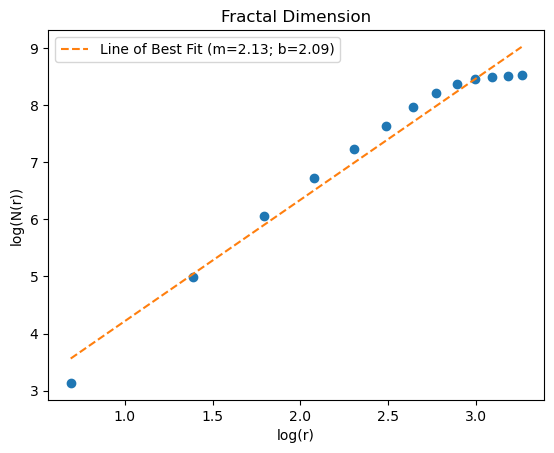

In [13]:
# Fractal Dimension
aggregate = np.argwhere(space)

# center
x_0 = length // 2
y_0 = length // 2
z_0 = length // 2

# radius
r = np.sqrt((aggregate[:,0] - x_0)**2 + (aggregate[:,1] - y_0)**2 + (aggregate[:,2] - z_0)**2)


r_array = np.arange(2, int(r.max()) + 1, 2)                             # radii starting at r = 5 to r_max (basically) with increments of 5
N_array = [np.sum(r <= R) for R in r_array]                             # Number of occupied blocks from center to radius

log_r = np.log(r_array)
log_N = np.log(N_array)

fit = np.polyfit(log_r, log_N, 1)
slope = fit[0]                              # Fractal dimension (Not the same as capacity dimension I think?)
b = fit[1]

print(f"Fractal dimension:", slope)

overlay = slope * log_r + b

plt.figure()
plt.plot(log_r, log_N, 'o')
plt.plot(log_r, overlay, '--' ,label=f'Line of Best Fit (m={slope:.2f}; b={b:.2f})') 
plt.xlabel('log(r)')
plt.ylabel('log(N(r))')
plt.title('Fractal Dimension')
plt.legend()
plt.show()